# Monte Carlo Risk Module — Audit & Calibration (BTC 15m)

**Scope:** everything that can be tuned **from candles alone** — no trade log required.
The decision-threshold tuning that *does* need real trades lives in `mc_trade_validation.ipynb`.

**What this notebook decides:**
1. `rolling_window` — how many bars to estimate sigma from.
2. `regime_sigma_multipliers` — how much to widen tails in stressed regimes.
3. `path_method` — GBM vs Bootstrap for BTC.
4. `num_simulations` — enough for stable, non-flickering decisions.
5. `horizon_bars` — relative to `max_holding_bars`.

**Engine fixes applied (all of them):**
- **#1** — Bootstrap now applies `regime_sigma_multipliers` (previously only GBM did).
- **#2** — Bootstrap honors `drift_mode='zero'` (demeans the resampled pool), so a trending BTC window
  no longer injects drift into the conservative paths. (Use `drift_mode='historical'` to keep the trend.)
- **#3** — `main.py` forces UTF-8 stdout (no `UnicodeEncodeError` on cp1251 consoles).
- **#4** — `monte_carlo` is now an importable package (`from monte_carlo.engine import …` works).
- **#5** — `decision.py` VaR reason wording fixed. **#6** — optimizer tunes `min_expected_pnl_r`.
  **#7** — the broken optimizer test fixed.

**Dataset:** `data/processed/btc_15m.csv` — BTC 15-minute candles, **2020-01-01 → 2025-03-15** (~182k bars).

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "monte_carlo"))

from config import MCConfig
from decision import DecisionConfig
from engine import run_monte_carlo_analysis
from market_state import MarketState
from trade_candidate import TradeCandidate
from stats import compute_sigma_and_drift
from path_generator import generate_paths

df = pd.read_csv(ROOT / "data/processed/btc_15m.csv")
df["open_time"] = pd.to_datetime(df["open_time"], errors="coerce")
df = df.sort_values("open_time").reset_index(drop=True)
close = pd.to_numeric(df["close"], errors="coerce").dropna().to_numpy()
logret = np.diff(np.log(close))
print(f"rows={len(df):,}  {df.open_time.iloc[0]} -> {df.open_time.iloc[-1]}  last_close={close[-1]:,.2f}")

rows=182,343  2020-01-01 00:00:00 -> 2025-03-15 23:45:00  last_close=84,338.44


## §1 — Volatility (`sigma`) calibration

`compute_sigma_and_drift` takes the rolling std of log returns over the last `rolling_window` bars.
Shorter window = more reactive but noisier; longer = smoother but laggy. Below: per-window sigma on
the most-recent bars, and the **full-history** rolling-20 sigma to see how volatile BTC's 15m bar is
across regimes.

Sigma on the MOST RECENT window (note: tail of data is a calm period):
 window  sigma/bar    %/bar  ~annualized %
      5   0.000585 0.058490      10.948726
     10   0.000567 0.056658      10.605765
     15   0.000700 0.069957      13.095284
     20   0.000684 0.068419      12.807330
     30   0.000797 0.079656      14.910786
     50   0.000923 0.092256      17.269304
    100   0.001166 0.116551      21.817231

Full-history rolling-20 sigma percentiles (50/80/90/95/99): [0.0023  0.00382 0.00506 0.00643 0.01085]
  p90/p50 = 2.20x    p99/p50 = 4.71x


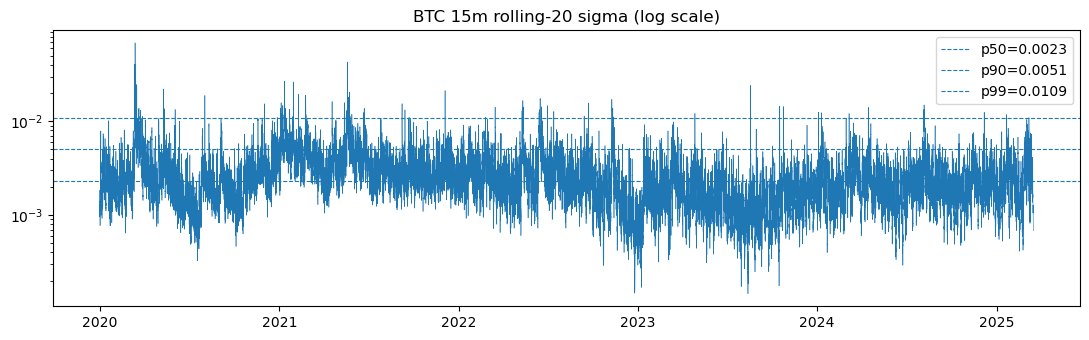

In [2]:
rows = []
for w in (5, 10, 15, 20, 30, 50, 100):
    cfg = MCConfig(rolling_window=w, drift_mode="zero")
    s, _ = compute_sigma_and_drift(close[-(w + 1):], cfg)
    rows.append((w, s, s * 100, s * np.sqrt(96 * 365) * 100))
tbl = pd.DataFrame(rows, columns=["window", "sigma/bar", "%/bar", "~annualized %"])
print("Sigma on the MOST RECENT window (note: tail of data is a calm period):")
print(tbl.to_string(index=False))

roll20 = pd.Series(logret).rolling(20).std(ddof=1).dropna().to_numpy()
qs = np.quantile(roll20, [0.5, 0.8, 0.9, 0.95, 0.99])
print("\nFull-history rolling-20 sigma percentiles (50/80/90/95/99):", np.round(qs, 5))
print(f"  p90/p50 = {qs[2]/qs[0]:.2f}x    p99/p50 = {qs[4]/qs[0]:.2f}x")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df["open_time"].iloc[-len(roll20):], roll20, lw=0.4)
for q, lab in zip(qs[[0, 2, 4]], ["p50", "p90", "p99"]):
    ax.axhline(q, ls="--", lw=0.8, label=f"{lab}={q:.4f}")
ax.set_yscale("log"); ax.set_title("BTC 15m rolling-20 sigma (log scale)"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

**Findings:**
- Per-bar sigma on the recent tail is ~0.06%/bar — **anomalously calm**. The full-history median is
  ~0.23%/bar (≈4×). Lesson: **never calibrate sigma off a single fixed tail window** — the engine
  already does the right thing by recomputing sigma per-signal from each trade's own recent window.
  Keep `rolling_window=20` (responsive, ~5h of context) unless you want faster reaction (→ 10–15).
- **Regime multipliers:** empirically `p90/p50 ≈ 2.2×` and `p99/p50 ≈ 4.7×`. The current defaults
  (`HIGH_VOL=1.25`, `CRASH=1.5`) only lift median sigma to ~p65/p70 — **too low for BTC 15m**.
  If your regime label is trend/structure-based (not already vol-based), a better starting point is
  `HIGH_VOL≈2.0`, `CRASH≈3.5`, to be validated. These now take effect under **both** GBM and Bootstrap (fix #1).

## §2 — GBM vs Bootstrap on real BTC

The live strategy (`code/main.py`) uses **fixed 1% SL** and **RR=3.0** TP, partial 0.5 at 1R, ATR×2 trail.
We replay exactly that shape and compare path methods on a recent 500-bar window. Both run with
`drift_mode='zero'` (fix #2 now demeans the Bootstrap pool too), so this isolates **tail shape**
(GBM normal vs Bootstrap empirical), not drift.

   method action  prob_loss     VaR_r    CVaR_r     EV_r    Kelly       PF
      GBM REJECT     0.5002 -0.791445 -0.946017 0.008463 0.021346 1.044615
BOOTSTRAP REDUCE     0.6160 -1.000000 -1.000000 0.176720 0.089192 1.302541


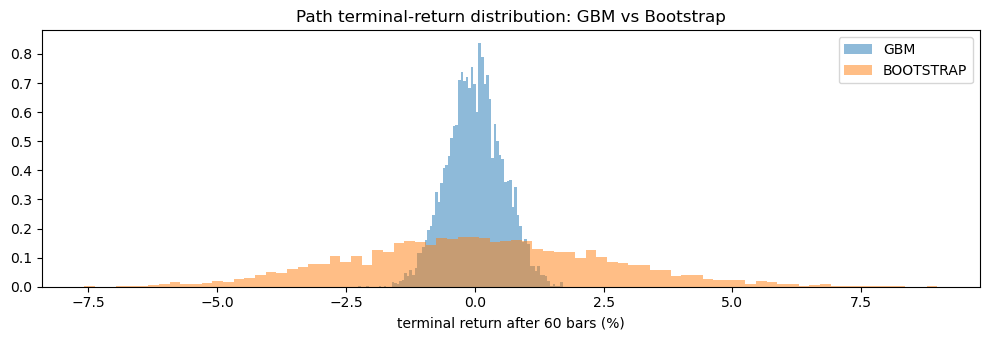

In [3]:
N = 500
closes = close[-N:]
rets = np.diff(np.log(closes)).tolist()
S0 = float(closes[-1])

def make_ms(regime="NEUTRAL"):
    return MarketState(recent_close_prices=closes.tolist(), recent_returns=rets,
                       atr=S0 * 0.01, sigma=0.0, drift=0.0, regime=regime, timestamp="cal")

def make_long(sl=0.01, tp=0.03, max_bars=50):
    return TradeCandidate(direction="LONG", entry_price=S0, stop_loss=S0 * (1 - sl),
        partial_tp_price=S0 * (1 + tp), partial_close_fraction=0.5, trailing_mode="ATR_BASED",
        atr=S0 * sl * 0.5, trailing_atr_multiple=2.0, max_holding_bars=max_bars,
        planned_size=1.0, risk_pct=0.01, regime="NEUTRAL")

dc = DecisionConfig()
comp = []
for method in ("GBM", "BOOTSTRAP"):
    cfg = MCConfig(num_simulations=5000, horizon_bars=60, random_seed=42,
                   drift_mode="zero", path_method=method, bootstrap_lookback=500)
    d = run_monte_carlo_analysis(make_long(), make_ms(), cfg, dc, passive_mode=False)
    comp.append((method, d.action, d.prob_loss, d.var_r, d.cvar_r, d.expected_pnl_r, d.kelly_fraction, d.profit_factor))
print(pd.DataFrame(comp, columns=["method", "action", "prob_loss", "VaR_r", "CVaR_r", "EV_r", "Kelly", "PF"]).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.5))
for method, c in (("GBM", "C0"), ("BOOTSTRAP", "C1")):
    cfg = MCConfig(num_simulations=5000, horizon_bars=60, random_seed=7,
                   drift_mode="zero", path_method=method, bootstrap_lookback=500)
    ms = make_ms(); ms.sigma, ms.drift = compute_sigma_and_drift(ms.recent_close_prices, cfg)
    paths = generate_paths(ms, cfg)
    term_r = (paths[:, -1] / S0 - 1.0) * 100
    ax.hist(term_r, bins=80, alpha=0.5, label=method, color=c, density=True)
ax.set_xlabel("terminal return after 60 bars (%)"); ax.set_title("Path terminal-return distribution: GBM vs Bootstrap")
ax.legend(); plt.tight_layout(); plt.show()

**Findings:**
- Compare the printed metrics row-by-row. With drift removed from both (fix #2), the difference is purely
  **tail shape**: Bootstrap's terminal distribution is visibly **fatter-tailed / skewed** vs GBM's
  symmetric bell, so its VaR_r / CVaR_r / prob_loss reflect BTC's real extremes that GBM's normal tails miss.
- **Recommendation for BTC tails: `path_method='BOOTSTRAP'`** with `bootstrap_lookback≈256–500`. Use GBM
  only as a fast sanity check or when <60 bars of history are available.
- *(Whether to also carry the recent trend — `drift_mode='historical'` or raw Bootstrap — is a
  strategy-calibration question answered in `mc_trade_validation.ipynb`, not here.)*

## §3 — `num_simulations`: how many paths for a stable decision?

A decision that flips between runs because of Monte Carlo noise is dangerous near a threshold.
We measure the std of `prob_loss` across 5 different seeds at each simulation count.

 num_simulations  mean_prob_loss  std_across_seeds
             500         0.49760          0.017545
            1000         0.50220          0.013977
            2000         0.50110          0.010988
            5000         0.49692          0.008826
           10000         0.49748          0.003482


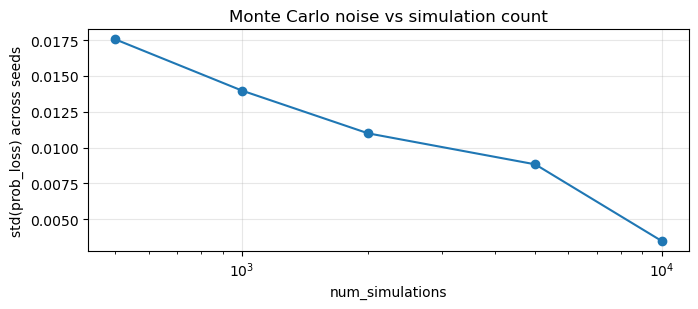

In [4]:
rows = []
for ns in (500, 1000, 2000, 5000, 10000):
    vals = [run_monte_carlo_analysis(make_long(), make_ms(),
            MCConfig(num_simulations=ns, horizon_bars=60, random_seed=s, drift_mode="zero"),
            dc, passive_mode=False).prob_loss for s in range(5)]
    rows.append((ns, np.mean(vals), np.std(vals)))
stab = pd.DataFrame(rows, columns=["num_simulations", "mean_prob_loss", "std_across_seeds"])
print(stab.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(stab.num_simulations, stab.std_across_seeds, "o-")
ax.set_xscale("log"); ax.set_xlabel("num_simulations"); ax.set_ylabel("std(prob_loss) across seeds")
ax.set_title("Monte Carlo noise vs simulation count"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Findings:** seed-to-seed `prob_loss` noise falls from ±0.018 (500 sims) to ±0.0035 (10k).
At 2000 sims the ±0.011 wobble can flip a decision sitting near a 0.55 boundary. **Use
`num_simulations=10_000` in production**, and raise `num_simulations_for_opt` to ~1000 inside the
optimizer where the average over many trials absorbs the noise.

## §4 — `horizon_bars` vs `max_holding_bars`

`replay_trade` clamps every path at `max_holding_bars`, so paths generated beyond it are never read.
The default `horizon_bars=500` with `max_holding_bars=50` is wasted work — but how much?

In [5]:
rows = []
for hz in (60, 200, 500):
    cfg = MCConfig(num_simulations=10000, horizon_bars=hz, random_seed=1, drift_mode="zero")
    t = time.time()
    run_monte_carlo_analysis(make_long(max_bars=50), make_ms(), cfg, dc, passive_mode=False)
    rows.append((hz, round(time.time() - t, 3)))
print(pd.DataFrame(rows, columns=["horizon_bars", "seconds (10k sims)"]).to_string(index=False))
print("\nNote: paths beyond max_holding_bars=50 are generated but never replayed.")

 horizon_bars  seconds (10k sims)
           60               0.195
          200               0.232
          500               0.318

Note: paths beyond max_holding_bars=50 are generated but never replayed.


**Findings:** the cost is mostly memory (an N×501 float array) plus a modest ~1.7× wall-time
(0.32s vs 0.19s) — not the 10× one might fear, because path generation is vectorized and the replay
loop is bounded by `max_holding_bars`. Still, free savings: **set `horizon_bars = max_holding_bars + ~10`**
(e.g. 60 for a 50-bar cap). Keep a small margin so paths are never truncated (the engine warns if
`max_holding_bars > horizon_bars`).

## §5 — Recommended `MCConfig` for BTC 15m

| Param | Default | Recommended | Why |
|---|---|---|---|
| `path_method` | `'GBM'` | **`'BOOTSTRAP'`** | Captures BTC fat tails/skew (§2) |
| `bootstrap_lookback` | 252 | **256–500** | ~3–5 days of 15m context; stable tails |
| `num_simulations` | 10000 | **10000** | Keeps decision noise ±0.0035 (§3) |
| `num_simulations_for_opt` | 500 | **1000** | Less per-trial noise inside the optimizer |
| `rolling_window` | 20 | **20** (10–15 if more reactive) | ~5h context; good responsiveness (§1) |
| `horizon_bars` | 500 | **`max_holding_bars + 10`** | Paths beyond the cap are unused (§4) |
| `drift_mode` | `'zero'` | **`'zero'` for risk-screening; `'historical'` for a trend strategy** | Zero is conservative; honored in Bootstrap now (fix #2). See validation notebook |
| `regime_sigma_multipliers` | `{}` | **`{'HIGH_VOL':2.0,'CRASH':3.5}`** | Defaults too low vs BTC p90/p99 (§1); now effective under GBM **and** Bootstrap (fix #1) |

**Metric caveats (interpretation, handled in the validation notebook):** `VaR_r`/`CVaR_r` gates are
largely inert for SL-dominated BTC trades (often ≈ −1R); `prob_sl_hit` counts winning trailing exits as
"stops". Lean threshold decisions on `prob_loss`/`EV`/`Kelly`.

In [6]:
recommended = MCConfig(
    path_method="BOOTSTRAP",
    bootstrap_lookback=256,
    num_simulations=10_000,
    num_simulations_for_opt=1_000,
    rolling_window=20,
    horizon_bars=60,           # = max_holding_bars(50) + margin
    drift_mode="zero",         # 'historical' for a trend-following strategy (see validation notebook)
    regime_sigma_multipliers={"HIGH_VOL": 2.0, "CRASH": 3.5},
)
print(recommended)

MCConfig(num_simulations=10000, horizon_bars=60, use_log_returns=True, drift_mode='zero', sigma_mode='historical', rolling_window=20, random_seed=None, var_confidence=0.95, cvar_confidence=0.95, path_method='BOOTSTRAP', bootstrap_lookback=256, regime_sigma_multipliers={'HIGH_VOL': 2.0, 'CRASH': 3.5}, num_simulations_for_opt=1000)
